In [1]:
###################################################################################################
#
# Copyright (C) 2025 Analog Devices, Inc. All Rights Reserved.
#
# Analog Devices, Inc. Default Copyright Notice:
#
###################################################################################################

import os
import sys
import importlib
from collections import defaultdict

import torch
import numpy as np
from tqdm import tqdm
from torch.utils import data

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.preprocessing import minmax_scale

sys.path.append(os.path.dirname(os.getcwd()))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'models'))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'losses'))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'metrics'))

import parse_qat_yaml
from distiller import apputils

import ai8x
from datasets import nilm

C:\Users\MTinaco\Dev\Algorithm\max7800x\ai8x-training\distiller\build\__editable__.distiller-0.4.0rc0-py3-none-any\distiller\summary_graph.py:27: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
%matplotlib inline

## Create test and train sets and visualize sample item/s

In [3]:
device = "cpu"
#CHANGE ME: Change below path to folder that contains or will contain dataset
#           (Data loader will create and use PascalVOC folder ubder this main root folder)
#           Below is an example where a path under Ubuntu root folder ('/'): /data2/ml/ 
#           is used for data files'
data_path = os.path.join('../', 'data')

class Args:
    def __init__(self, act_mode_8bit):
        self.act_mode_8bit = act_mode_8bit
        self.truncate_testset = False

simulate = False
args = Args(act_mode_8bit=simulate)
wide = True

train_set, test_set = \
    nilm.ukdale_128_seq2point_stratified_compand_get_datasets((data_path, args), load_train=True, load_test=True)


In [4]:
classes = ["fridge_freezer", "kettle", "washer_dryer", "dish_washer", "microwave"]
appliance_data = [
    {
        "type": "fridge",
        "window": 50,
        "min": 0.0,
        "max": 259.0,
        "on_power_threshold": 50
    },
    {
        "type":"kettle",
        "window": 50,
        "min": 0.0,
        "max": 2417.0,
        "on_power_threshold": 10
    },
    {
        "type":"washer dryer",
        "window": 50,
        "min": 0.0,
        "max": 2055.0,
        "on_power_threshold": 20
    },
    {
        "type":"dish washer",
        "window": 10,
        "min": 0.0,
        "max": 2439.0,
        "on_power_threshold": 10
    },
    {
        "type":"microwave",
        "window": 50,
        "min": 0.0,
        "max": 1605.0,
        "on_power_threshold": 200
    }
]

In [5]:
trained_checkpoint_path = os.path.join("..", "..", "ai8x-synthesis", "trained", "ai85-nilm-seq2point-128-qat8-q.pth.tar")
mod = importlib.import_module("ai85net-nilm-seq2point-128")

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Working with device:", device)

Working with device: cuda


In [7]:
train_batch_size = 256
test_dataloader = data.DataLoader(test_set, batch_size=train_batch_size, shuffle=False, drop_last=True)

## Model Quantization

In [8]:
qat_yaml_file_used_in_training = os.path.join(os.path.dirname(os.getcwd()), 'policies', 'qat_policy_nilm.yaml')
qat_policy = parse_qat_yaml.parse(qat_yaml_file_used_in_training)

checkpoint = torch.load(trained_checkpoint_path)

ai8x.set_device(device=85, simulate=True, round_avg=False)

model = mod.AI85NILMSeq2Point128(num_classes=5, num_channels=1, dimensions=(128, 1), bias=True)

# Fuse the BN parameters into conv layers before Quantization Aware Training (QAT)
ai8x.fuse_bn_layers(model)

model = apputils.load_lean_checkpoint(model, trained_checkpoint_path, model_device=device)

ai8x.initiate_qat(model, qat_policy)
ai8x.update_model(model)

model = model.to(device)

Configuring device: MAX78000, simulate=True.


### Data Quantization

In [9]:
def quantize_input(data, num_bits=8, compand=False, mu=10):
    """
    Quantize audio
    """
    step_size = 2.0 / 2**num_bits
    max_val = 2**num_bits - 1
    q_data = np.round((data - (-1.0)) / step_size)
    q_data = np.clip(q_data, 0, max_val)
    return np.uint8(q_data)

## Inference

In [10]:
model.eval()

num_quantiles = 5
softmax = torch.nn.Softmax(dim=1)

inputs_ = torch.empty(len(test_dataloader)*train_batch_size)

predstates = torch.empty(len(test_dataloader)*train_batch_size, 5)
targstates = torch.empty(len(test_dataloader)*train_batch_size, 5)
predrms = torch.empty(len(test_dataloader)*train_batch_size, 5)
targrms = torch.empty(len(test_dataloader)*train_batch_size, 5)

with torch.no_grad():
    for idx, (inputs, target) in enumerate(tqdm(test_dataloader)):
        inputs = quantize_input(inputs)
        inputs = torch.from_numpy(inputs) - 128.0
        input_last_sample = inputs[:,:,-1].squeeze()
        inputs = inputs.to(device)
        outputs = model(inputs)

        output_state = outputs[:,:2*5].reshape(train_batch_size, 2, -1)
        output_power = outputs[:,2*5:].reshape(train_batch_size, num_quantiles, -1)

        prob, pred_state = torch.max(softmax(output_state), 1)      # Gets the softmax per class
        pred_power = output_power[:,2]                              # Gets the 0.5 percentil or, 3rd quantile

        inputs_[idx*train_batch_size:(idx+1)*train_batch_size] = input_last_sample
        predstates[idx*train_batch_size:(idx+1)*train_batch_size, :5] = pred_state
        targstates[idx*train_batch_size:(idx+1)*train_batch_size, :5] = target[0]
        predrms[idx*train_batch_size:(idx+1)*train_batch_size, :5] = pred_power
        targrms[idx*train_batch_size:(idx+1)*train_batch_size, :5] = target[1]


100%|██████████| 4384/4384 [06:53<00:00, 10.59it/s]


## Postprocessing

In [354]:
def mu_law_expand(y, mu=255):
    return np.sign(y) * (1 / mu) * (np.expm1(np.abs(y) * np.log1p(mu)))


def adaptive_dc_removal_2d(signal_2d, samples_per_window=100):
    """
    Removes low-frequency DC component from each column of a 2D signal array.
    
    Parameters:
    - signal_2d: 2D numpy array (time x channels)
    - window_minutes: duration of the moving average window
    - sample_rate_hz: sampling rate (Hz), e.g., 1/6 Hz for 1 sample every 6s
    
    Returns:
    - dc-removed 2D signal (same shape as input)
    """
    if samples_per_window < 1:
        samples_per_window = 1

    kernel = np.ones(samples_per_window) / samples_per_window

    filtered = np.empty_like(signal_2d)

    for i in range(signal_2d.shape[1]):  # for each channel
        offset_estimate = np.convolve(signal_2d[:, i], kernel, mode='same')
        filtered[:, i] = signal_2d[:, i] - offset_estimate

    return filtered

In [ ]:
inputs_array = inputs_.cpu().detach().numpy()

predstate_array = predstates.cpu().detach().numpy()
targstate_array = targstates.cpu().detach().numpy()
predrms_array = predrms.cpu().detach().numpy()
targrms_array = targrms.cpu().detach().numpy()

# Denormalization
inputs_array = inputs_array + 127
inputs_array = minmax_scale(inputs_array, feature_range=(0, 1))
inputs_array = mu_law_expand(inputs_array)

# NOTE: wide=True
if wide:
    predrms_array = (predrms_array + 2**15) / 2**16
    predrms_array = adaptive_dc_removal_2d(predrms_array, samples_per_window=100000)
    predrms_array = predrms_array * 255
else:
    predrms_array = predrms_array + 127
    predrms_array = predrms_array.clip(min=0, max=255)

targrms_array = (targrms_array + 1) / 2 * 255

In [395]:
section_slice = slice(5000, 27000)

### Input

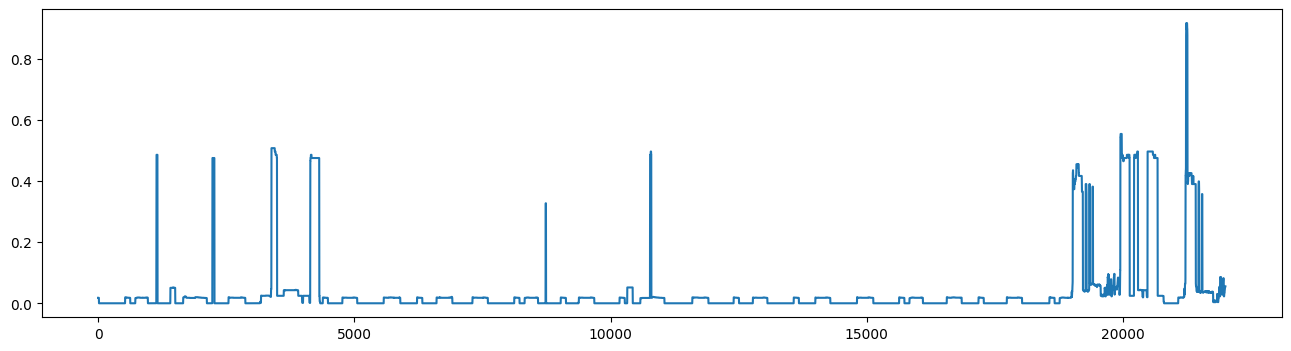

In [396]:
fig, axs = plt.subplots(1)
fig.set_size_inches(16, 4)
axs.plot(inputs_array[section_slice])

### RMS Target vs. RMS Prediction

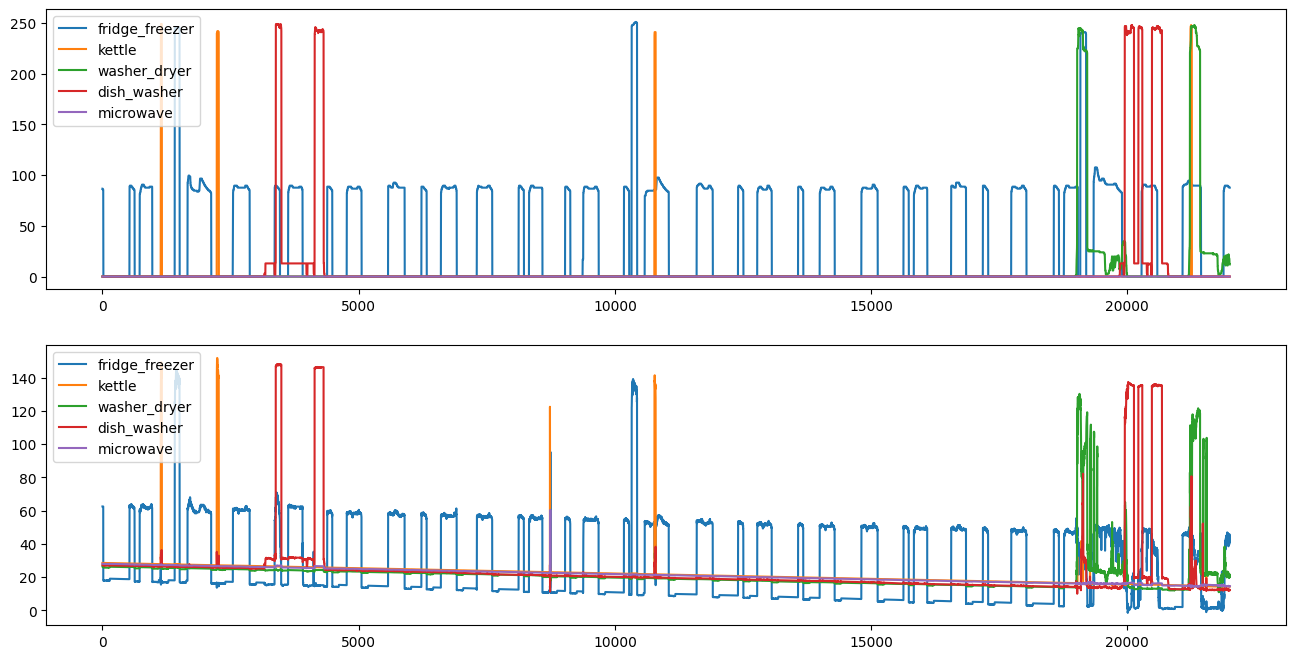

In [397]:
fig, axs = plt.subplots(2)
fig.set_size_inches(16, 8)
axs[0].plot(targrms_array[section_slice])
axs[0].legend(classes)
axs[1].plot(predrms_array[section_slice])
axs[1].legend(classes)

### Plot RMS x State Target vs. RMS RMS x State Prediction

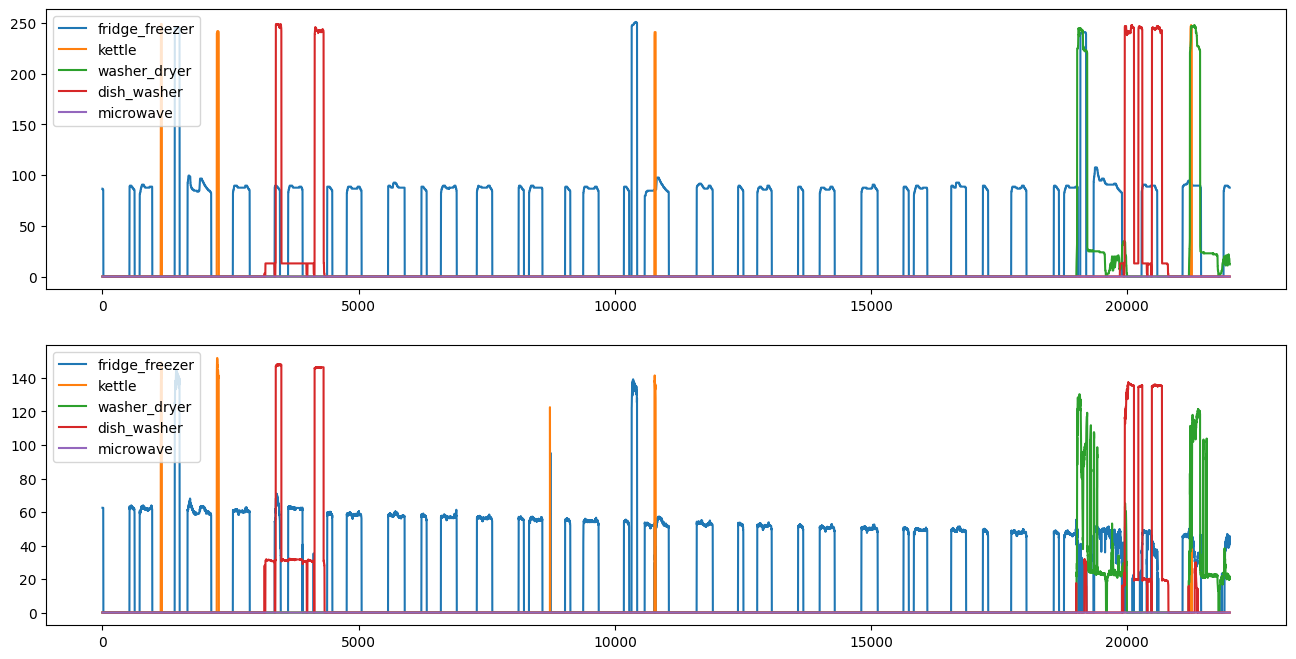

In [398]:
fig, axs = plt.subplots(2)
fig.set_size_inches(16, 8)
axs[0].plot(targrms_array[section_slice]*targstate_array[section_slice])
axs[0].legend(classes)
axs[1].plot(predrms_array[section_slice]*predstate_array[section_slice])
axs[1].legend(classes)

## Evaluation metrics

In [399]:
def EAC(target, prediction):
    num = np.abs(target - prediction).sum(axis=0)
    den = 2*target.sum(axis=0)
    return (1 - num/den)

def MAE(target, prediction):
    return np.abs(target - prediction).mean(axis=0)

def NDE(target, prediction):
    return np.sum((target - prediction) ** 2) / np.sum((target ** 2), axis=0)

def _compute_tp_fp_fn(true_targets, predictions, axis=1):
    # axis: axis for instance
    tp = np.sum(true_targets * predictions, axis=axis).astype('float32')
    fp = np.sum(np.logical_not(true_targets) * predictions,
                axis=axis).astype('float32')
    fn = np.sum(true_targets * np.logical_not(predictions),
                axis=axis).astype('float32')

    return (tp, fp, fn)

def _example_f1_score(true_targets, predictions, per_sample=False, axis=1):
    tp, fp, fn = _compute_tp_fp_fn(true_targets, predictions, axis=axis)

    numerator = 2*tp
    denominator = (np.sum(true_targets,axis=axis).astype('float32') + np.sum(predictions,axis=axis).astype('float32'))

    zeros = np.where(denominator == 0)[0]

    denominator = np.delete(denominator,zeros)
    numerator = np.delete(numerator,zeros)

    example_f1 = numerator/denominator


    if per_sample:
        f1 = example_f1
    else:
        f1 = np.mean(example_f1)

    return f1

## Denormalization

In [400]:
targrms_denorm_array = np.zeros(targrms_array.shape)
predrms_denorm_array = np.zeros(predrms_array.shape)

for idx, app in enumerate(appliance_data):
    min_ = app["min"]
    max_ = app["max"]
    targrms_denorm_array[:, idx] = minmax_scale(targrms_array[:, idx], feature_range=(min_, max_))
    predrms_denorm_array[:, idx] = minmax_scale(predrms_array[:, idx], feature_range=(min_, max_))

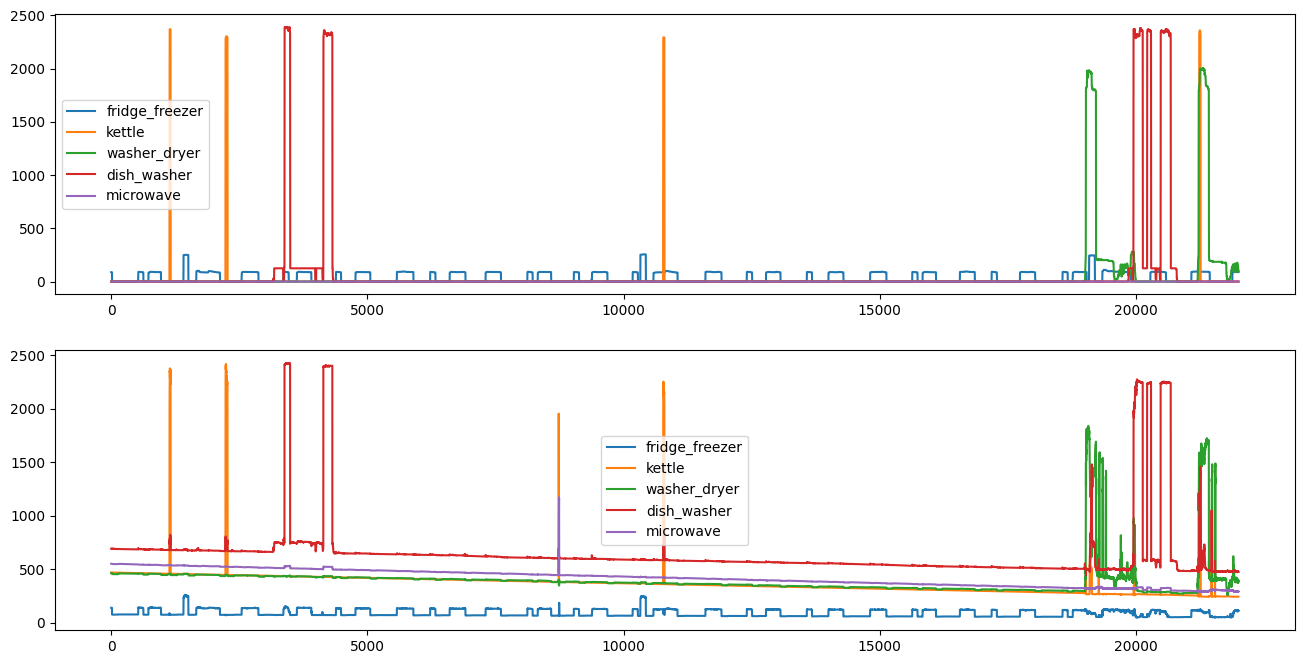

In [401]:
fig, axs = plt.subplots(2)
fig.set_size_inches(16, 8)
axs[0].plot(targrms_denorm_array[section_slice])
axs[0].legend(classes)
axs[1].plot(predrms_denorm_array[section_slice])
axs[1].legend(classes)

In [402]:
targ_ensemble = targrms_denorm_array * targstate_array
pred_ensemble = predrms_denorm_array * predstate_array

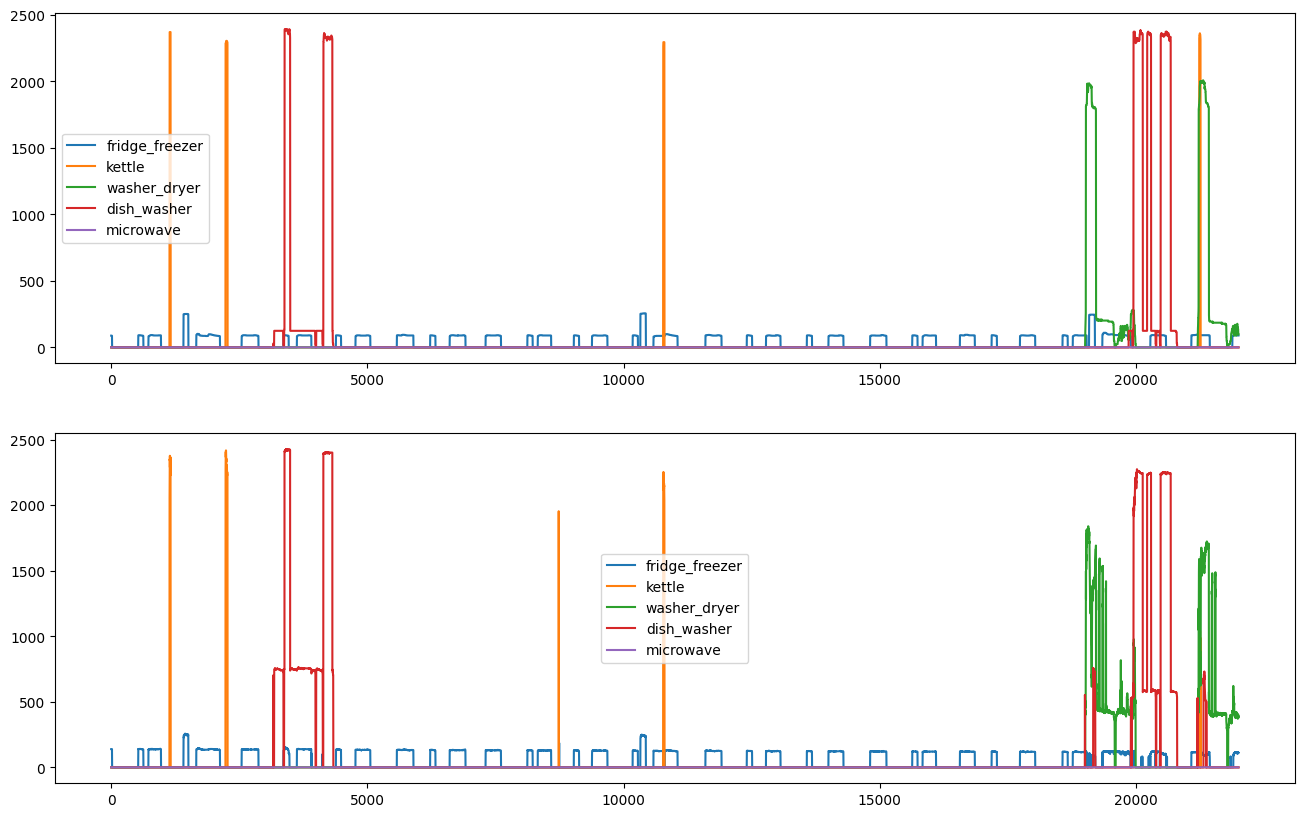

In [403]:
fig, axs = plt.subplots(2)
fig.set_size_inches(16, 10)
axs[0].plot(targ_ensemble[section_slice])
axs[0].legend(classes)
axs[1].plot(pred_ensemble[section_slice])
axs[1].legend(classes)

In [404]:
pure_rms_metrics = defaultdict(list)
ensemble_metrics = defaultdict(list)

for i in range(len(appliance_data)):
    pure_rms_metrics["EAC"].append(EAC(targrms_denorm_array[:,i], predrms_denorm_array[:, i]))
    pure_rms_metrics["MAE"].append(MAE(targrms_denorm_array[:,i], predrms_denorm_array[:, i]))
    pure_rms_metrics["NDE"].append(NDE(targrms_denorm_array[:,i], predrms_denorm_array[:, i]))
    pure_rms_metrics["F1"].append(_example_f1_score(targstate_array[:,i], predstate_array[:, i], per_sample=True, axis=0))

for i in range(len(appliance_data)):
    ensemble_metrics["EAC"].append(EAC(targ_ensemble[:, i], pred_ensemble[:, i]))
    ensemble_metrics["MAE"].append(MAE(targ_ensemble[:, i], pred_ensemble[:, i]))
    ensemble_metrics["NDE"].append(NDE(targ_ensemble[:, i], pred_ensemble[:, i]))
    ensemble_metrics["F1"].append(_example_f1_score(targstate_array[:,i], predstate_array[:, i], per_sample=True, axis=0))

pure_rms_metrics_df = pd.DataFrame(pure_rms_metrics, index=classes)
ensemble_metrics_df = pd.DataFrame(ensemble_metrics, index=classes)

In [405]:
# RMS

pure_rms_metrics_df

,EAC,MAE,NDE,F1
fridge_freezer,0.742430,19.617731,0.167653,0.985806
kettle,-1.453004,38.551942,0.683750,0.864086
washer_dryer,-0.287760,105.888405,0.325229,0.977154
dish_washer,-0.884493,269.303868,0.530225,0.964739
microwave,-12.541581,39.977248,5.612763,0.796928


In [406]:
# State x RMS

ensemble_metrics_df

,EAC,MAE,NDE,F1
fridge_freezer,0.944117,4.253635,0.051878,0.985806
kettle,0.792073,3.267778,0.266928,0.864086
washer_dryer,0.833610,13.662366,0.095815,0.977154
dish_washer,0.831472,24.070964,0.055848,0.964739
microwave,0.764824,0.691690,0.355765,0.796928
